# Machine Learning — Notebook 10
## Redes Neuronales: arquitectura, backprop conceptual y MLP práctico

### Objetivos
- Entender la **neurona artificial** como unidad básica de cómputo.
- Comprender la arquitectura de un **MLP** (perceptrón multicapa): capas, activaciones y forward pass.
- Entender **backpropagation** de forma conceptual: regla de la cadena aplicada al grafo computacional.
- Entrenar `MLPClassifier` y `MLPRegressor` de sklearn y ajustar sus hiperparámetros clave.
- Leer **curvas de aprendizaje** (train vs validación) para detectar overfitting.
- Aplicar **regularización**: L2 (`alpha`) y early stopping desde sklearn.
- Entender dropout conceptualmente y saber cuándo usarlo.
- Comparar MLP vs los modelos del curso en el mismo dataset.

### Ideas clave
- Una red neuronal **apila transformaciones no lineales**: $\mathbf{h}^{(l)} = \sigma(W^{(l)}\mathbf{h}^{(l-1)} + \mathbf{b}^{(l)})$.
- ReLU domina en la práctica: simple, no sufre de vanishing gradient, y funciona bien.
- El **gradiente fluye hacia atrás** por la regla de la cadena → el optimizador ajusta todos los pesos.
- Sin regularización, una red grande **sobreajusta rápido**: la curva de val-loss sube mientras train-loss baja.
- **Early stopping** corta el entrenamiento cuando el val-loss deja de mejorar → regularizador gratuito.
- **L2 (`alpha`)** penaliza pesos grandes → reduce la capacidad efectiva de la red.
- **Dropout** (conceptual): apaga neuronas aleatoriamente durante el train → requiere Keras/PyTorch.
- MLP requiere **escalado** (igual que KNN y SVM).

> Todo el notebook usa **sklearn** (`MLPClassifier` / `MLPRegressor`): rápido, sin dependencias extra.

---
## 0) Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    mean_squared_error, r2_score
)
from sklearn.datasets import make_classification, make_moons, make_regression

RANDOM_STATE = 7
rng = np.random.default_rng(RANDOM_STATE)

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 200)

---
## 1) La neurona artificial y el MLP: arquitectura

### 1a) La neurona

Una neurona recibe un vector de entradas, calcula una suma ponderada y aplica una función de activación:

$$
z = \mathbf{w}^\top \mathbf{x} + b, \qquad a = \sigma(z)
$$

- $\mathbf{w}$: pesos (parámetros aprendidos).
- $b$: sesgo (bias).
- $\sigma$: función de activación (ReLU, tanh, sigmoide…).

Sin la activación $\sigma$, apilar capas no añade expresividad: seguiría siendo una transformación lineal.

### 1b) El MLP (Multilayer Perceptron)

Un MLP apila $L$ capas de neuronas. Para la capa $l$:

$$
\mathbf{h}^{(l)} = \sigma\!\left(W^{(l)}\,\mathbf{h}^{(l-1)} + \mathbf{b}^{(l)}\right)
$$

- Capa de entrada: $\mathbf{h}^{(0)} = \mathbf{x}$.
- Capas ocultas: aplican la activación.
- Capa de salida: sigmoide (clasificación binaria), softmax (multiclase), o identidad (regresión).

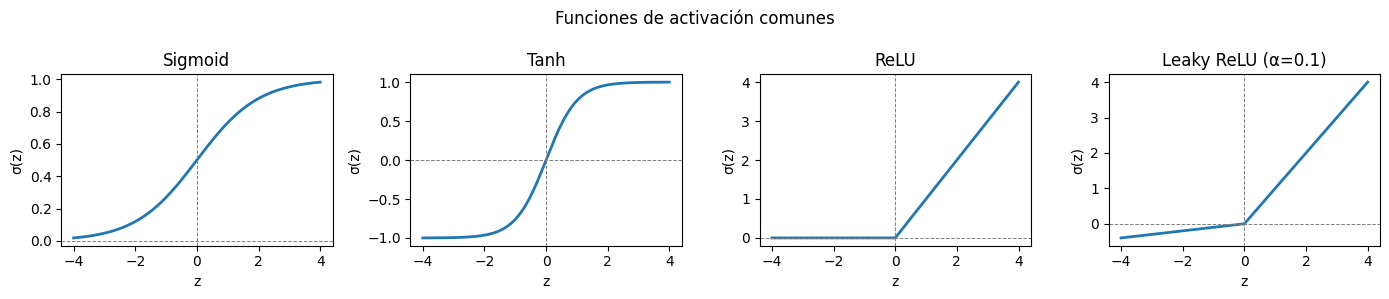

In [2]:
# 1.1 Visualizar las funciones de activación más comunes
z = np.linspace(-4, 4, 300)

activaciones = {
    "Sigmoid": 1 / (1 + np.exp(-z)),
    "Tanh":    np.tanh(z),
    "ReLU":    np.maximum(0, z),
    "Leaky ReLU (α=0.1)": np.where(z > 0, z, 0.1 * z),
}

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, (name, values) in zip(axes, activaciones.items()):
    ax.plot(z, values, linewidth=2)
    ax.axhline(0, color="gray", linewidth=0.7, linestyle="--")
    ax.axvline(0, color="gray", linewidth=0.7, linestyle="--")
    ax.set_title(name)
    ax.set_xlabel("z")
    ax.set_ylabel("σ(z)")

plt.suptitle("Funciones de activación comunes")
plt.tight_layout()
plt.show()

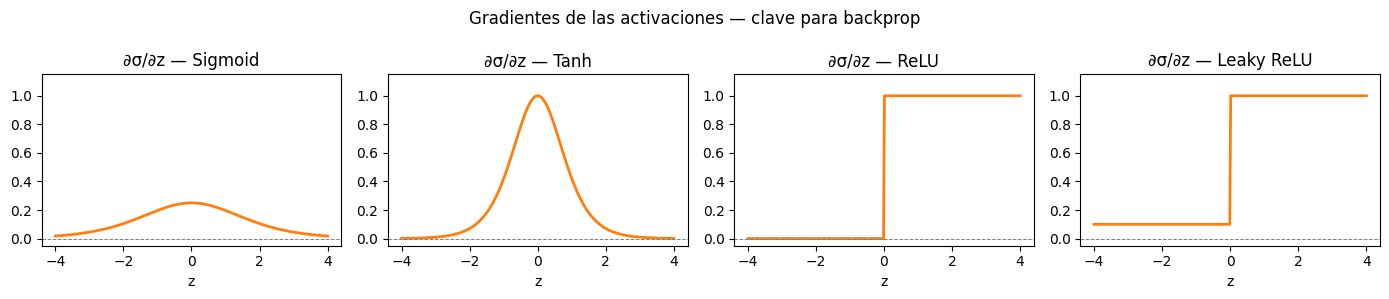

Sigmoid y Tanh tienen gradiente ~0 en las colas → vanishing gradient.
ReLU tiene gradiente constante (1) para z>0 → flujo de gradiente estable.


In [3]:
# 1.2 Gradiente de cada activación (importa para backprop)
grad = {
    "Sigmoid": (1/(1+np.exp(-z))) * (1 - 1/(1+np.exp(-z))),
    "Tanh":    1 - np.tanh(z)**2,
    "ReLU":    (z > 0).astype(float),
    "Leaky ReLU": np.where(z > 0, 1.0, 0.1),
}

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, (name, values) in zip(axes, grad.items()):
    ax.plot(z, values, linewidth=2, color="tab:orange")
    ax.axhline(0, color="gray", linewidth=0.7, linestyle="--")
    ax.set_title(f"∂σ/∂z — {name}")
    ax.set_xlabel("z")
    ax.set_ylim(-0.05, 1.15)

plt.suptitle("Gradientes de las activaciones — clave para backprop")
plt.tight_layout()
plt.show()

print("Sigmoid y Tanh tienen gradiente ~0 en las colas → vanishing gradient.")
print("ReLU tiene gradiente constante (1) para z>0 → flujo de gradiente estable.")

---
## 2) Backpropagation: la idea central

La red aprende minimizando una función de pérdida $\mathcal{L}$ (e.g., cross-entropy).  
El optimizador necesita $\frac{\partial \mathcal{L}}{\partial w}$ para cada parámetro $w$.  
Backprop aplica la **regla de la cadena** hacia atrás por el grafo computacional:

$$
\frac{\partial \mathcal{L}}{\partial W^{(l)}} =
\underbrace{\frac{\partial \mathcal{L}}{\partial \mathbf{h}^{(l)}}}_{\text{error de capa }l}
\cdot
\underbrace{\frac{\partial \mathbf{h}^{(l)}}{\partial z^{(l)}}}_{\text{grad. activación}}
\cdot
\underbrace{\frac{\partial z^{(l)}}{\partial W^{(l)}}}_{= \mathbf{h}^{(l-1)}}
$$

**Intuición:**
1. **Forward pass** → calcular la predicción y la pérdida.
2. **Backward pass** → propagar el error hacia atrás, capa por capa.
3. **Update** → $W^{(l)} \leftarrow W^{(l)} - \eta \cdot \frac{\partial \mathcal{L}}{\partial W^{(l)}}$

El **vanishing gradient** ocurre cuando las derivadas de la activación son muy pequeñas (sigmoid en las colas): el gradiente se multiplica por valores < 1 en cada capa → en las primeras capas llega casi a cero.

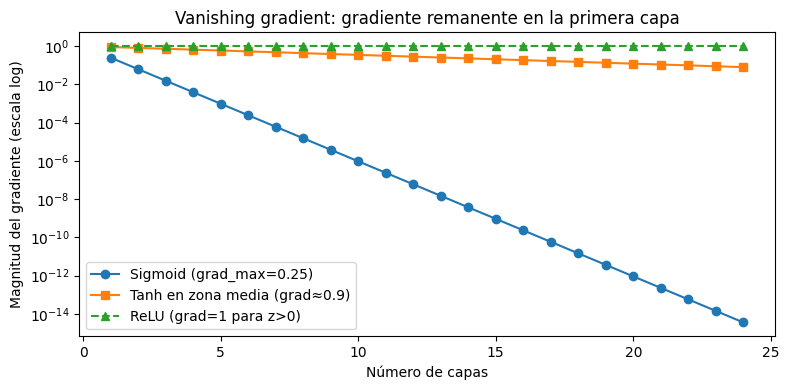

Sigmoid — gradiente después de  5 capas: 0.000977
Sigmoid — gradiente después de 10 capas: 9.54e-07
ReLU   — gradiente después de 10 capas: 1.00  (no se desvanece)


In [4]:
# 2.1 Vanishing gradient: ¿qué queda del gradiente después de L capas?
L_values = np.arange(1, 25)

# En el peor caso de la cadena: multiplicar el gradiente de la activación L veces
# Sigmoid: gradiente máximo ≈ 0.25 | Tanh: gradiente máximo = 1 | ReLU: gradiente = 1 (para z>0)
plt.figure(figsize=(8, 4))
plt.plot(L_values, 0.25**L_values, marker="o", label="Sigmoid (grad_max=0.25)")
plt.plot(L_values, 0.9**L_values,  marker="s", label="Tanh en zona media (grad≈0.9)")
plt.plot(L_values, np.ones(len(L_values)), marker="^", label="ReLU (grad=1 para z>0)", linestyle="--")
plt.yscale("log")
plt.xlabel("Número de capas")
plt.ylabel("Magnitud del gradiente (escala log)")
plt.title("Vanishing gradient: gradiente remanente en la primera capa")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Sigmoid — gradiente después de  5 capas: {0.25**5:.6f}")
print(f"Sigmoid — gradiente después de 10 capas: {0.25**10:.2e}")
print(f"ReLU   — gradiente después de 10 capas: {1.0**10:.2f}  (no se desvanece)")

---
## 3) MLPClassifier (sklearn): primeros pasos

sklearn implementa MLP con la API habitual (`fit` / `predict` / `predict_proba`).  
Los hiperparámetros más importantes:

| Parámetro | Qué controla | Default |
|---|---|---|
| `hidden_layer_sizes` | Arquitectura: `(100,)` = 1 capa de 100; `(64, 32)` = 2 capas | `(100,)` |
| `activation` | Función de activación oculta: `'relu'`, `'tanh'`, `'logistic'` | `'relu'` |
| `solver` | Optimizador: `'adam'` (recomendado), `'sgd'`, `'lbfgs'` | `'adam'` |
| `alpha` | Regularización L2 — penaliza pesos grandes | `0.0001` |
| `max_iter` | Épocas máximas | `200` |
| `early_stopping` | Detener si val-accuracy no mejora | `False` |
| `validation_fraction` | Fracción del train usada como val (si early_stopping=True) | `0.1` |
| `n_iter_no_change` | Épocas de paciencia para early stopping | `10` |

In [5]:
# 3.1 Dataset tabular simulado
X, y = make_classification(
    n_samples=2000, n_features=12, n_informative=6,
    n_redundant=3, weights=[0.68, 0.32],
    class_sep=1.0, flip_y=0.04, random_state=RANDOM_STATE
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Balance:", pd.Series(y_train).value_counts(normalize=True).round(3).to_dict())

Train: (1500, 12) | Test: (500, 12)
Balance: {0: 0.673, 1: 0.327}


In [6]:
# 3.2 MLP básico: 1 capa oculta, 64 neuronas
# IMPORTANTE: siempre escalar antes del MLP
mlp_base = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(64,),
        activation="relu",
        max_iter=300,
        random_state=RANDOM_STATE
    ))
])

mlp_base.fit(X_train, y_train)
pred  = mlp_base.predict(X_test)
proba = mlp_base.predict_proba(X_test)[:, 1]

print(f"Accuracy  : {accuracy_score(y_test, pred):.4f}")
print(f"F1        : {f1_score(y_test, pred):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, proba):.4f}")
print(f"Iteraciones usadas: {mlp_base.named_steps['mlp'].n_iter_}")

Accuracy  : 0.8980
F1        : 0.8371
ROC-AUC   : 0.9248
Iteraciones usadas: 300


/opt/homebrew/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


---
## 4) Efecto de la arquitectura: profundidad y ancho

La arquitectura define la **capacidad** del modelo.  
- Red angosta y profunda: extrae jerarquías de features.  
- Red ancha y poco profunda: aproxima funciones complejas con menos capas.  

Con datos tabulares estructurados, **una o dos capas ocultas** suelen ser suficientes.

In [7]:
# 4.1 Comparar arquitecturas: ancho vs profundidad
arquitecturas = {
    "(16,)": (16,),
    "(64,)": (64,),
    "(128,)": (128,),
    "(64, 32)": (64, 32),
    "(128, 64)": (128, 64),
    "(128, 64, 32)": (128, 64, 32),
}

rows = []
for name, arch in arquitecturas.items():
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPClassifier(
            hidden_layer_sizes=arch, activation="relu",
            max_iter=300, random_state=RANDOM_STATE
        ))
    ])
    pipe.fit(X_train, y_train)
    mlp_obj = pipe.named_steps["mlp"]
    n_params = sum(w.size for w in mlp_obj.coefs_) + sum(b.size for b in mlp_obj.intercepts_)
    rows.append({
        "Arquitectura": name,
        "Parámetros": n_params,
        "Acc_train": accuracy_score(y_train, pipe.predict(X_train)),
        "Acc_test":  accuracy_score(y_test,  pipe.predict(X_test)),
        "F1_test":   f1_score(y_test, pipe.predict(X_test)),
        "ROC_AUC":   roc_auc_score(y_test, pipe.predict_proba(X_test)[:, 1]),
    })

df_arch = pd.DataFrame(rows).set_index("Arquitectura").round(4)
df_arch

/opt/homebrew/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/homebrew/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/homebrew/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/homebrew/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/homebrew/lib/python3.13/site-packages/sklearn/neural_network/_multi

,Parámetros,Acc_train,Acc_test,F1_test,ROC_AUC
Arquitectura,,,,,
"(16,)",225,0.9227,0.898,0.8360,0.9155
"(64,)",897,0.9433,0.898,0.8371,0.9248
"(128,)",1793,0.9560,0.906,0.8527,0.9271
"(64, 32)",2945,0.9920,0.906,0.8563,0.9247
"(128, 64)",9985,1.0000,0.890,0.8297,0.9219
"(128, 64, 32)",12033,1.0000,0.884,0.8176,0.9174


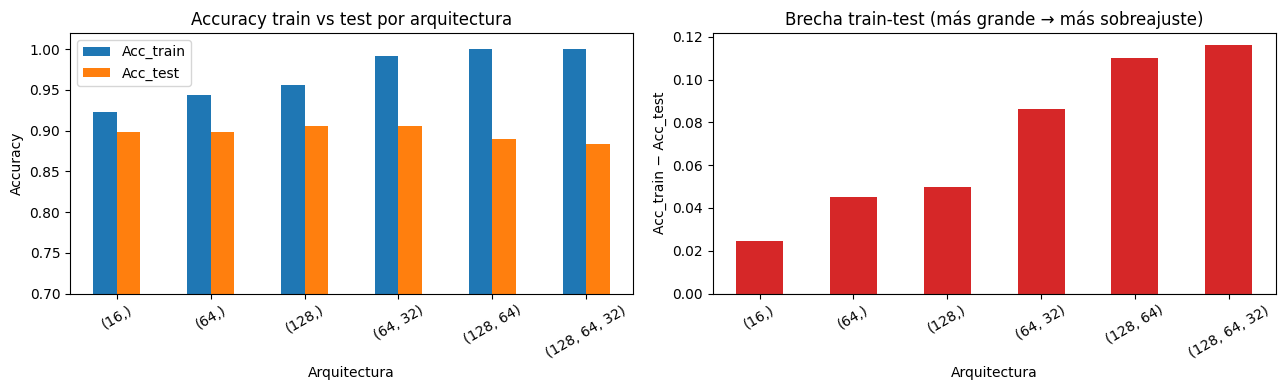

In [8]:
# 4.2 Brecha train-test como señal de sobreajuste
df_arch["Gap_train_test"] = (df_arch["Acc_train"] - df_arch["Acc_test"]).round(4)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df_arch[["Acc_train", "Acc_test"]].plot(kind="bar", ax=axes[0], ylim=(0.7, 1.02), rot=30)
axes[0].set_title("Accuracy train vs test por arquitectura")
axes[0].set_ylabel("Accuracy")

df_arch["Gap_train_test"].plot(kind="bar", ax=axes[1], color="tab:red", rot=30)
axes[1].set_title("Brecha train-test (más grande → más sobreajuste)")
axes[1].set_ylabel("Acc_train − Acc_test")
axes[1].axhline(0, color="gray", linewidth=0.8)

plt.tight_layout()
plt.show()

---
## 5) Curvas de aprendizaje: detectar overfitting

La curva de pérdida muestra cómo evoluciona el error por época:

| Patrón | Diagnóstico |
|---|---|
| Train ↓, val ↓ (ambas altas) | Underfitting — modelo demasiado simple |
| Train ↓, val ↓ (ambas bajas) | Buen ajuste |
| Train ↓, val ↑ | **Overfitting** — el modelo memoriza el train |
| Train y val estables y similares | Convergido |

sklearn expone `loss_curve_` (train) y `validation_scores_` (val) cuando `early_stopping=True`.

In [9]:
# 5.1 Escalar los datos una vez (para usarlos directamente sin Pipeline)
sc = StandardScaler()
X_tr_sc = sc.fit_transform(X_train)
X_te_sc = sc.transform(X_test)

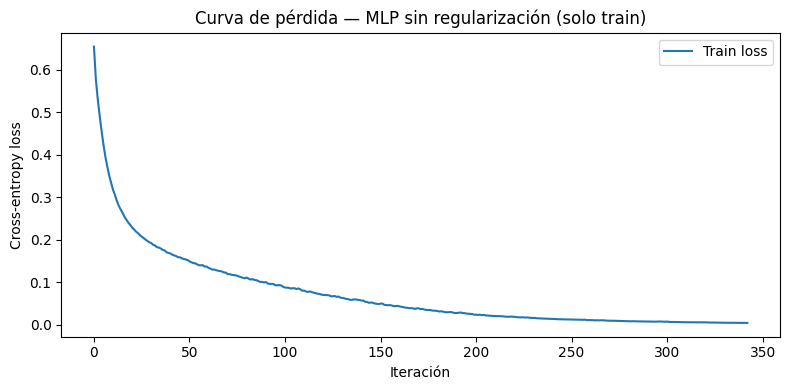

Iteraciones: 343 | Train acc: 1.0000 | Test acc: 0.8880


In [10]:
# 5.2 MLP sin early stopping: solo vemos la curva de train
mlp_noreg = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    max_iter=400,
    early_stopping=False,
    random_state=RANDOM_STATE
)
mlp_noreg.fit(X_tr_sc, y_train)

plt.figure(figsize=(8, 4))
plt.plot(mlp_noreg.loss_curve_, label="Train loss")
plt.xlabel("Iteración")
plt.ylabel("Cross-entropy loss")
plt.title("Curva de pérdida — MLP sin regularización (solo train)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Iteraciones: {mlp_noreg.n_iter_} | "
      f"Train acc: {accuracy_score(y_train, mlp_noreg.predict(X_tr_sc)):.4f} | "
      f"Test acc: {accuracy_score(y_test, mlp_noreg.predict(X_te_sc)):.4f}")

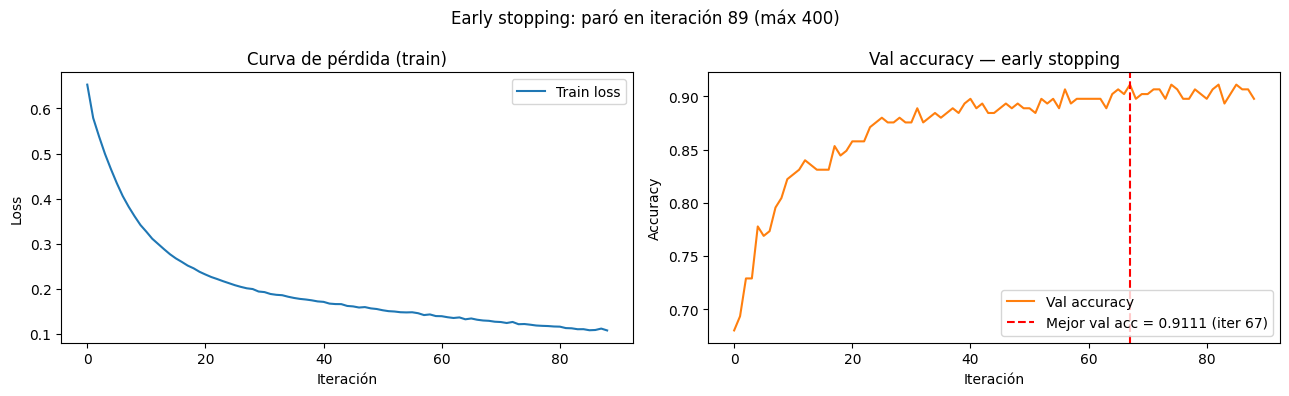

Iteraciones usadas: 89 de 400
Test accuracy: 0.8960


In [11]:
# 5.3 Con early_stopping=True: vemos val-score y el modelo para solo cuando conviene
mlp_es = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    max_iter=400,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=20,
    random_state=RANDOM_STATE
)
mlp_es.fit(X_tr_sc, y_train)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(mlp_es.loss_curve_, label="Train loss")
axes[0].set_xlabel("Iteración")
axes[0].set_ylabel("Loss")
axes[0].set_title("Curva de pérdida (train)")
axes[0].legend()

axes[1].plot(mlp_es.validation_scores_, color="tab:orange", label="Val accuracy")
best_iter = int(np.argmax(mlp_es.validation_scores_))
axes[1].axvline(best_iter, linestyle="--", color="red",
                label=f"Mejor val acc = {mlp_es.best_validation_score_:.4f} (iter {best_iter})")
axes[1].set_xlabel("Iteración")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Val accuracy — early stopping")
axes[1].legend()

plt.suptitle(f"Early stopping: paró en iteración {mlp_es.n_iter_} (máx 400)")
plt.tight_layout()
plt.show()

print(f"Iteraciones usadas: {mlp_es.n_iter_} de 400")
print(f"Test accuracy: {accuracy_score(y_test, mlp_es.predict(X_te_sc)):.4f}")

---
## 6) Regularización: L2 (`alpha`) y early stopping

### 6a) Regularización L2 — parámetro `alpha`

Añade una penalidad a la función de pérdida proporcional a la norma cuadrada de los pesos:

$$
\mathcal{L}_{\text{reg}}(\theta) = \mathcal{L}(\theta) + \frac{\alpha}{2} \sum_w w^2
$$

- `alpha` pequeño (≈ 0) → sin penalidad → la red puede sobreajustar.
- `alpha` grande → pesos pequeños → frontera más suave → más sesgo, menos varianza.

### 6b) Dropout (conceptual)

Dropout **apaga aleatoriamente** una fracción $p$ de neuronas en cada paso de entrenamiento:  
$\tilde{h}_i = h_i \cdot \text{Bernoulli}(1-p)$.  
Cada neurona aprende a ser útil *por sí sola*, sin depender de sus vecinas.  
En inferencia, todas las neuronas están activas y los pesos se escalan por $(1-p)$.  

> sklearn no implementa dropout; se necesita Keras o PyTorch. Este notebook usa `alpha` (L2) como regularizador equivalente.

In [12]:
# 6.1 Efecto de alpha (L2) sobre el overfitting
alpha_values = [1e-6, 1e-4, 1e-2, 0.1, 1.0, 10.0]

rows_alpha = []
for a in alpha_values:
    mlp_a = MLPClassifier(
        hidden_layer_sizes=(128, 64), activation="relu",
        max_iter=300, alpha=a,
        early_stopping=False,
        random_state=RANDOM_STATE
    )
    mlp_a.fit(X_tr_sc, y_train)
    rows_alpha.append({
        "alpha": a,
        "Acc_train": accuracy_score(y_train, mlp_a.predict(X_tr_sc)),
        "Acc_test":  accuracy_score(y_test,  mlp_a.predict(X_te_sc)),
        "F1_test":   f1_score(y_test, mlp_a.predict(X_te_sc)),
        "ROC_AUC":   roc_auc_score(y_test, mlp_a.predict_proba(X_te_sc)[:, 1]),
    })

df_alpha = pd.DataFrame(rows_alpha).set_index("alpha").round(4)
df_alpha

/opt/homebrew/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/homebrew/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/homebrew/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


,Acc_train,Acc_test,F1_test,ROC_AUC
alpha,,,,
0.000001,1.0000,0.894,0.8359,0.9221
0.000100,1.0000,0.890,0.8297,0.9219
0.010000,1.0000,0.894,0.8359,0.9203
0.100000,0.9973,0.892,0.8302,0.9215
1.000000,0.9513,0.904,0.8452,0.9305
10.000000,0.8440,0.800,0.5968,0.8723


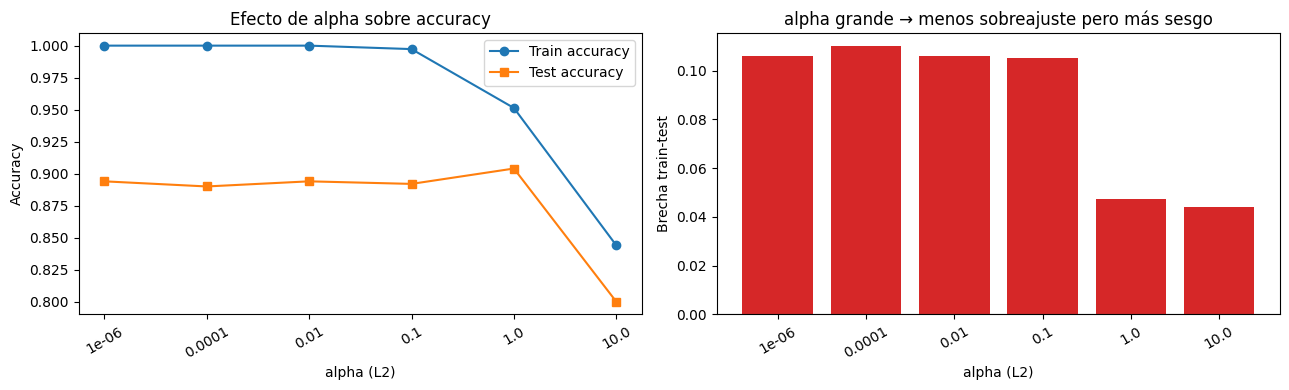

In [13]:
# 6.2 Visualizar el efecto de alpha: trade-off sesgo-varianza
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

alpha_log = [np.log10(a) for a in alpha_values]
alpha_labels = [str(a) for a in alpha_values]

axes[0].plot(alpha_labels, df_alpha["Acc_train"], marker="o", label="Train accuracy")
axes[0].plot(alpha_labels, df_alpha["Acc_test"],  marker="s", label="Test accuracy")
axes[0].set_xlabel("alpha (L2)")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Efecto de alpha sobre accuracy")
axes[0].legend()
axes[0].tick_params(axis='x', rotation=30)

gap = df_alpha["Acc_train"] - df_alpha["Acc_test"]
axes[1].bar(alpha_labels, gap, color="tab:red")
axes[1].axhline(0, color="gray", linewidth=0.8)
axes[1].set_xlabel("alpha (L2)")
axes[1].set_ylabel("Brecha train-test")
axes[1].set_title("alpha grande → menos sobreajuste pero más sesgo")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [14]:
# 6.3 Combinar: alpha óptimo + early stopping
# Estrategia: CV para elegir alpha, luego early_stopping para no sobre-entrenar
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

alpha_cv = [1e-4, 1e-3, 1e-2, 0.1]
rows_cv = []
for a in alpha_cv:
    pipe_cv = Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPClassifier(
            hidden_layer_sizes=(64, 32), activation="relu",
            max_iter=300, alpha=a,
            early_stopping=True, validation_fraction=0.15,
            n_iter_no_change=15,
            random_state=RANDOM_STATE
        ))
    ])
    scores = cross_val_score(pipe_cv, X_train, y_train, cv=cv, scoring="roc_auc")
    rows_cv.append({"alpha": a, "ROC_AUC_CV_mean": scores.mean(), "ROC_AUC_CV_std": scores.std()})

df_cv = pd.DataFrame(rows_cv).set_index("alpha").round(4)
print("CV por alpha:")
print(df_cv)

CV por alpha:
        ROC_AUC_CV_mean  ROC_AUC_CV_std
alpha                                  
0.0001           0.9470          0.0190
0.0010           0.9454          0.0195
0.0100           0.9452          0.0193
0.1000           0.9453          0.0213


In [15]:
# 6.4 Entrenar modelo final con mejor alpha + early stopping
best_alpha = df_cv["ROC_AUC_CV_mean"].idxmax()
print(f"Mejor alpha (CV): {best_alpha}")

mlp_final = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(64, 32), activation="relu",
        max_iter=300, alpha=best_alpha,
        early_stopping=True, validation_fraction=0.15,
        n_iter_no_change=15,
        random_state=RANDOM_STATE
    ))
])
mlp_final.fit(X_train, y_train)
pred_f  = mlp_final.predict(X_test)
proba_f = mlp_final.predict_proba(X_test)[:, 1]

print(f"Iteraciones usadas: {mlp_final.named_steps['mlp'].n_iter_}")
print(f"Test Accuracy : {accuracy_score(y_test, pred_f):.4f}")
print(f"Test F1       : {f1_score(y_test, pred_f):.4f}")
print(f"Test ROC-AUC  : {roc_auc_score(y_test, proba_f):.4f}")

Mejor alpha (CV): 0.0001
Iteraciones usadas: 43
Test Accuracy : 0.8760
Test F1       : 0.7987
Test ROC-AUC  : 0.9133


---
## 7) MLP para fronteras no lineales (2D — visualización)

Una ventaja clave del MLP sobre la regresión logística es que puede aprender **cualquier frontera**.  
Visualizamos esto en datos no lineales (lunas): logística falla, MLP no.

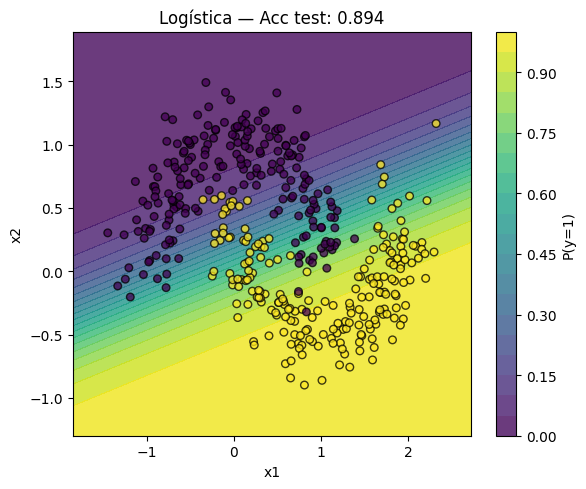

In [16]:
# 7.1 Dataset no lineal: lunas
X_moon, y_moon = make_moons(n_samples=600, noise=0.20, random_state=RANDOM_STATE)
X_m_tr, X_m_te, y_m_tr, y_m_te = train_test_split(
    X_moon, y_moon, test_size=0.30, random_state=RANDOM_STATE, stratify=y_moon
)

def plot_boundary(model, X, y, title, steps=300):
    x1_min, x1_max = X[:, 0].min() - 0.4, X[:, 0].max() + 0.4
    x2_min, x2_max = X[:, 1].min() - 0.4, X[:, 1].max() + 0.4
    xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, steps),
                            np.linspace(x2_min, x2_max, steps))
    proba = model.predict_proba(np.c_[xx1.ravel(), xx2.ravel()])[:, 1].reshape(xx1.shape)
    plt.figure(figsize=(6, 5))
    plt.contourf(xx1, xx2, proba, levels=20, alpha=0.8)
    plt.colorbar(label="P(y=1)")
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", s=30, alpha=0.75)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.tight_layout()
    plt.show()

# Logística falla en datos no lineales
lr_moon = Pipeline([("sc", StandardScaler()), ("lr", LogisticRegression())])
lr_moon.fit(X_m_tr, y_m_tr)
plot_boundary(lr_moon, X_m_tr, y_m_tr,
              f"Logística — Acc test: {accuracy_score(y_m_te, lr_moon.predict(X_m_te)):.3f}")

/opt/homebrew/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


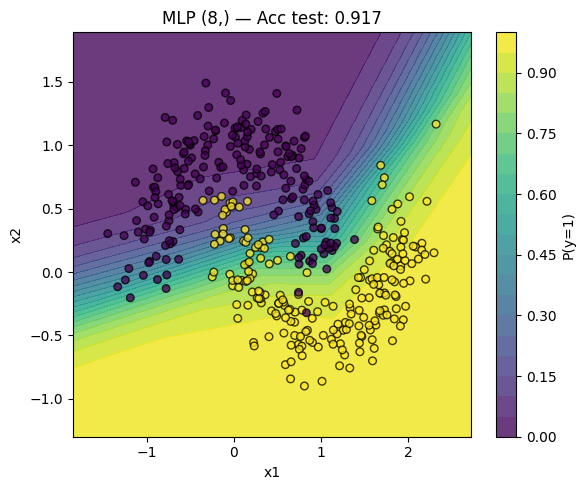

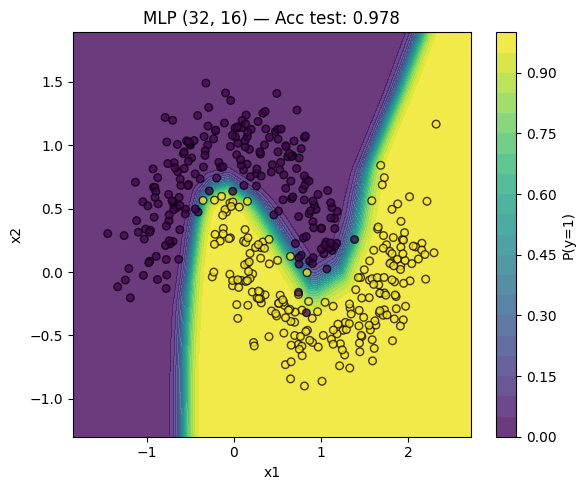

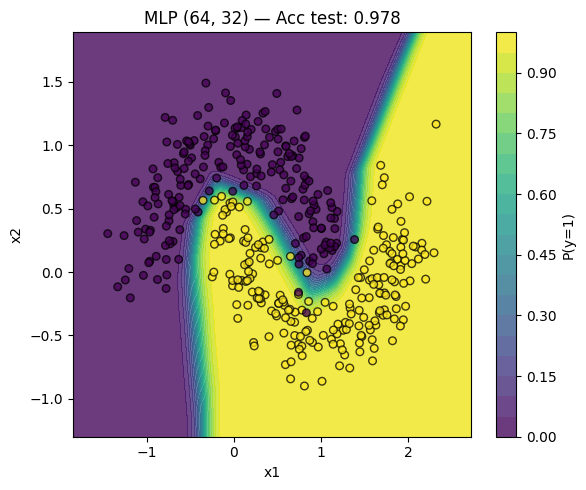

In [17]:
# 7.2 MLP con distintas arquitecturas: la frontera se vuelve arbitraria
configs_moon = [
    ("MLP (8,)",     (8,)),
    ("MLP (32, 16)", (32, 16)),
    ("MLP (64, 32)", (64, 32)),
]

for name, arch in configs_moon:
    mlp_m = Pipeline([
        ("sc",  StandardScaler()),
        ("mlp", MLPClassifier(
            hidden_layer_sizes=arch, activation="relu",
            max_iter=500, random_state=RANDOM_STATE
        ))
    ])
    mlp_m.fit(X_m_tr, y_m_tr)
    acc_te = accuracy_score(y_m_te, mlp_m.predict(X_m_te))
    plot_boundary(mlp_m, X_m_tr, y_m_tr, f"{name} — Acc test: {acc_te:.3f}")

---
## 8) MLP para regresión (`MLPRegressor`)

La misma arquitectura funciona para regresión: la capa de salida tiene una neurona con activación **identidad** y la pérdida es MSE.  
Las mismas reglas: escalar, controlar arquitectura, usar early stopping.

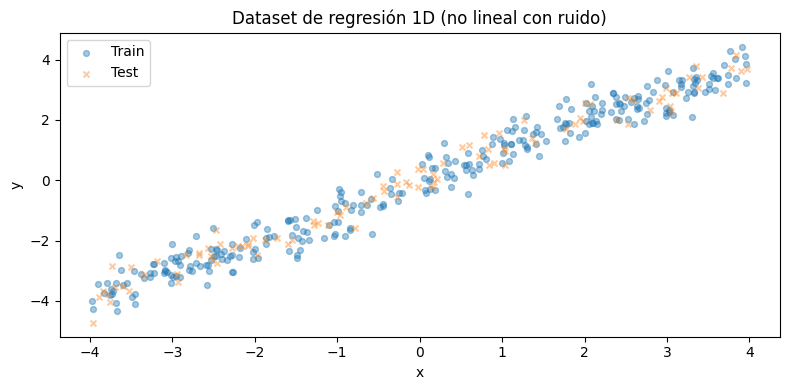

In [18]:
# 8.1 Función no lineal 1D
n_reg = 400
X_reg = rng.uniform(-4, 4, size=(n_reg, 1))
noise = rng.normal(0, 0.4, size=n_reg)
y_reg = np.sin(X_reg[:, 0]) + 0.3 * X_reg[:, 0]**2 * np.sign(X_reg[:, 0]) + noise

X_r_tr, X_r_te, y_r_tr, y_r_te = train_test_split(
    X_reg, y_reg, test_size=0.25, random_state=RANDOM_STATE
)
x_plot = np.linspace(-4, 4, 400).reshape(-1, 1)

plt.figure(figsize=(8, 4))
plt.scatter(X_r_tr, y_r_tr, alpha=0.4, s=18, label="Train")
plt.scatter(X_r_te, y_r_te, alpha=0.4, s=18, marker="x", label="Test")
plt.title("Dataset de regresión 1D (no lineal con ruido)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

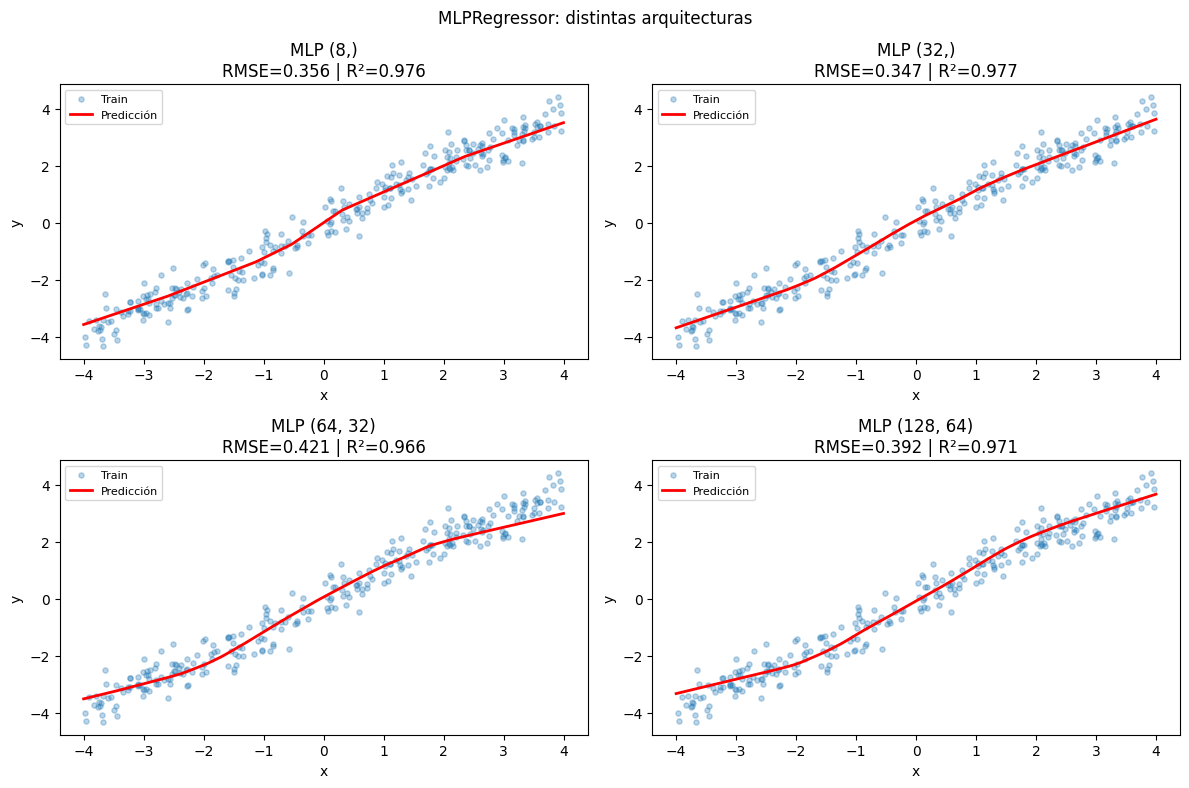

,RMSE_test,R2_test
Config,,
"MLP (8,)",0.3559,0.9760
"MLP (32,)",0.3473,0.9772
"MLP (64, 32)",0.4208,0.9665
"MLP (128, 64)",0.3920,0.9709


In [19]:
# 8.2 Comparar MLPRegressor con distintas arquitecturas
configs_reg = [
    ("MLP (8,)",      (8,)),
    ("MLP (32,)",     (32,)),
    ("MLP (64, 32)",  (64, 32)),
    ("MLP (128, 64)", (128, 64)),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()
reg_results = []

for ax, (name, arch) in zip(axes, configs_reg):
    pipe_r = Pipeline([
        ("sc",  StandardScaler()),
        ("mlp", MLPRegressor(
            hidden_layer_sizes=arch, activation="relu",
            max_iter=500, early_stopping=True,
            validation_fraction=0.15, n_iter_no_change=20,
            random_state=RANDOM_STATE
        ))
    ])
    pipe_r.fit(X_r_tr, y_r_tr)
    y_pred = pipe_r.predict(X_r_te)
    rmse = np.sqrt(mean_squared_error(y_r_te, y_pred))
    r2   = r2_score(y_r_te, y_pred)
    reg_results.append({"Config": name, "RMSE_test": rmse, "R2_test": r2})

    ax.scatter(X_r_tr, y_r_tr, alpha=0.3, s=14, label="Train")
    ax.plot(x_plot, pipe_r.predict(x_plot), color="red", linewidth=2, label="Predicción")
    ax.set_title(f"{name}\nRMSE={rmse:.3f} | R²={r2:.3f}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend(fontsize=8)

plt.suptitle("MLPRegressor: distintas arquitecturas")
plt.tight_layout()
plt.show()

pd.DataFrame(reg_results).set_index("Config").round(4)

---
## 9) Comparación final: MLP vs modelos del curso

Todos los modelos usan el mismo split train/test y la misma métrica.

In [20]:
# 9.1 Entrenar todos los modelos del curso sobre el dataset tabular
lr_f  = Pipeline([("sc", StandardScaler()), ("lr", LogisticRegression(max_iter=3000))]).fit(X_train, y_train)
rf_f  = RandomForestClassifier(n_estimators=150, random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train)
svm_f = Pipeline([("sc", StandardScaler()), ("svm", SVC(kernel="rbf", C=10.0, gamma="scale", probability=True))]).fit(X_train, y_train)
dum_f = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)

model_dict = {
    "Dummy":              (dum_f,     X_test),
    "LogReg":             (lr_f,      X_test),
    "RandomForest":       (rf_f,      X_test),
    "SVM RBF":            (svm_f,     X_test),
    "MLP (64,32)+ES+L2":  (mlp_final, X_test),
}

rows = []
for name, (model, Xte) in model_dict.items():
    pred  = model.predict(Xte)
    proba = model.predict_proba(Xte)[:, 1]
    rows.append({
        "Modelo":      name,
        "Accuracy":    accuracy_score(y_test, pred),
        "BalancedAcc": balanced_accuracy_score(y_test, pred),
        "F1":          f1_score(y_test, pred, zero_division=0),
        "ROC_AUC":     roc_auc_score(y_test, proba),
        "PR_AUC":      average_precision_score(y_test, proba),
    })

pd.DataFrame(rows).set_index("Modelo").round(4)

,Accuracy,BalancedAcc,F1,ROC_AUC,PR_AUC
Modelo,,,,,
Dummy,0.674,0.5000,0.0000,0.5000,0.3260
LogReg,0.724,0.6131,0.4103,0.6701,0.5254
RandomForest,0.902,0.8671,0.8361,0.9341,0.9009
SVM RBF,0.886,0.8616,0.8190,0.9243,0.8498
"MLP (64,32)+ES+L2",0.876,0.8447,0.7987,0.9133,0.8429


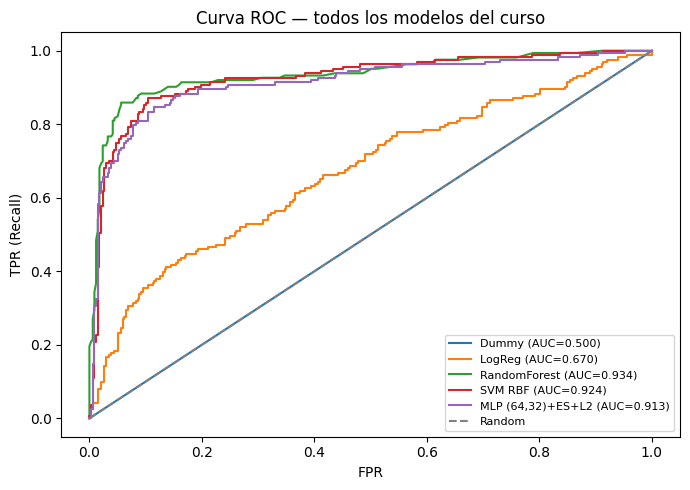

In [21]:
# 9.2 Curvas ROC — todos los modelos del curso
plt.figure(figsize=(7, 5))
for name, (model, Xte) in model_dict.items():
    proba = model.predict_proba(Xte)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
plt.xlabel("FPR")
plt.ylabel("TPR (Recall)")
plt.title("Curva ROC — todos los modelos del curso")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

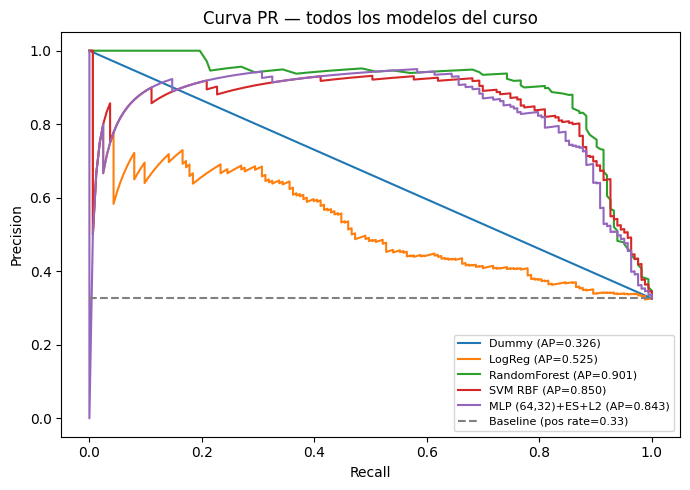

In [22]:
# 9.3 Curva PR
baseline_rate = y_test.mean()
plt.figure(figsize=(7, 5))
for name, (model, Xte) in model_dict.items():
    proba = model.predict_proba(Xte)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    plt.plot(rec, prec, label=f"{name} (AP={ap:.3f})")
plt.hlines(baseline_rate, 0, 1, linestyles="--", colors="gray",
           label=f"Baseline (pos rate={baseline_rate:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva PR — todos los modelos del curso")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

---
## 10) Ejercicios (Semana 10)

### Ejercicio 1 — Vanishing gradient
1. La sección 2 muestra que el gradiente de sigmoid después de 10 capas es ≈ $10^{-6}$.  
2. ¿Qué consecuencia práctica tiene esto para entrenar redes profundas con sigmoid?  
3. ¿Por qué ReLU resuelve el vanishing gradient? ¿Qué problema nuevo introduce (dead neurons)?

### Ejercicio 2 — Curva de aprendizaje y early stopping
1. Entrena un `MLPClassifier` con `hidden_layer_sizes=(256, 128)` y `early_stopping=False`.  
2. Grafica `loss_curve_`. ¿La pérdida converge suavemente o hay oscilaciones?  
3. Activa `early_stopping=True`. ¿En qué iteración para? ¿Mejora el test accuracy?

### Ejercicio 3 — Regularización L2
1. Fija la arquitectura `(128, 64)` y prueba `alpha` en `[0, 0.001, 0.01, 0.1, 1.0, 10.0]`.  
2. Grafica la brecha train-test en función de alpha.  
3. ¿Qué valor de alpha reduce el sobreajuste sin sacrificar demasiado el test accuracy?

### Ejercicio 4 — Arquitectura vs regularización
1. Compara dos estrategias contra el overfitting:  
   (a) Reducir la arquitectura de `(256, 128)` a `(32, 16)`.  
   (b) Mantener `(256, 128)` pero añadir `alpha=0.1`.  
2. ¿Cuál logra mejor test F1? ¿Cuál tiene menor brecha train-test?  
3. ¿Cuál preferirías en la práctica y por qué?

### Ejercicio 5 — Tabla comparativa final
Completa con tus propias palabras y observaciones de este notebook:

| Modelo | Requiere escalado | Maneja no linealidad | Interpretable | Regularización principal | Tiempo de entrenamiento |
|---|---|---|---|---|---|
| Logística | | | | | |
| Árbol de Decisión | | | | | |
| Random Forest | | | | | |
| SVM RBF | | | | | |
| MLP (sklearn) | | | | | |